In [1]:
import time
from pythonosc.udp_client import SimpleUDPClient
import os
import pathlib
import itertools
from music21 import (
    tempo,
    chord,
    note,
    stream,
    meter,
    duration,
    corpus,
    converter,
    serial,
    expressions,
    clef,
    key,
    instrument,
    layout,
)
import random
import xmltodict
import io
import yaml

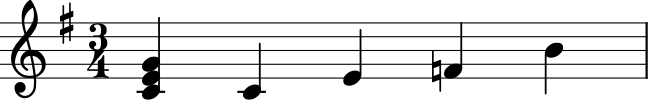

score-partwise:
  '@version': '4.0'
  defaults:
    scaling:
      millimeters: '7'
      tenths: '40'
  identification:
    creator:
      '#text': Music21
      '@type': composer
    encoding:
      encoding-date: '2025-04-30'
      software: music21 v.9.1.0
  movement-title: Music21 Fragment
  part:
    '@id': P2ddcdd93bd7e233ec45e4a35782aeb0e
    measure:
      '@implicit': 'no'
      '@number': '0'
      attributes:
        divisions: '10080'
        key:
          fifths: '1'
        time:
          beat-type: '4'
          beats: '3'
      note:
      - duration: '10080'
        pitch:
          octave: '4'
          step: C
        type: quarter
      - chord: null
        duration: '10080'
        pitch:
          octave: '4'
          step: E
        type: quarter
      - chord: null
        duration: '10080'
        pitch:
          octave: '4'
          step: G
        type: quarter
      - duration: '10080'
        pitch:
          octave: '4'
          step: C
        typ

In [2]:
OUTPUT_ABSPATH = pathlib.Path(os.environ.get("ARTIFACTS_ABSPATH", "/"))

s = stream.Stream()
p = stream.Part()

# m.append(layout.SystemLayout())

# s.staffLines = 10
p.append(instrument.Piano())
p.append(meter.TimeSignature("3/4"))
p.append(key.KeySignature(1))

m = stream.Measure()
# m.append(clef.AltoClef())
# m.append(clef.TrebleClef())

c = chord.Chord()
c.add(note.Note("C4"))
c.add(note.Note("E4"))
c.add(note.Note("G4"))

# m.append(clef.TrebleClef())
m.append(c)
for k in "cefb":
    n = note.Note(f"{k.upper()}4")
    m.append(n)

p.append(m)
s.append(p)

s.show()

# s.write("musicxml", fp=OUTPUT_ABSPATH / "3-notes.musicxml")
with open(s.write("musicxml"), "r") as f:
    python_obj = xmltodict.parse(f.read(), attr_prefix="@")
    yaml_obj = yaml.dump(python_obj)
print(yaml_obj)

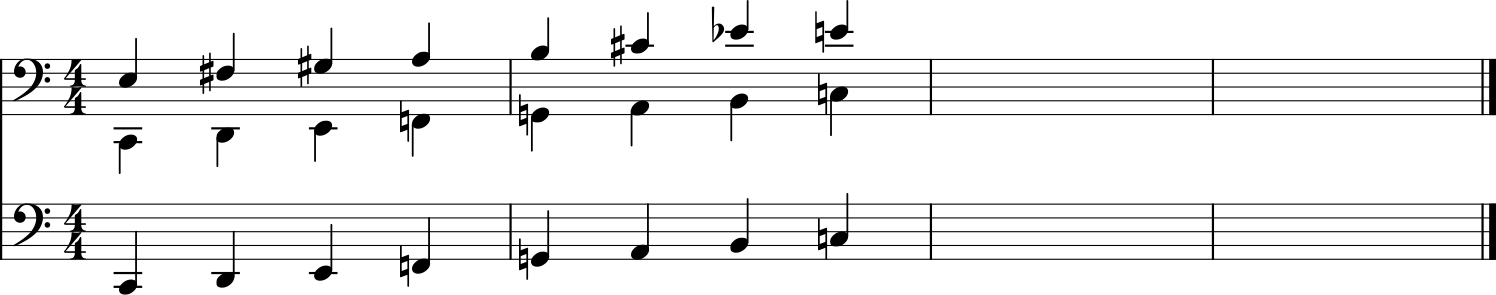

PosixPath('/utkusarioglu-com/workshops/signals-workshop/artifacts/climb.xml')

In [3]:
# environment.set("musicxmlColor", "white")
score = stream.Score()
piano = stream.Part()
bass = stream.Part()
piano_1 = stream.Voice()
piano_2 = stream.Voice()

notes = ["C4", "D4", "E4", "F4", "G4", "A4", "B4", "C5"]

for n in notes:
    melody_note = note.Note(n)
    piano_2.append(melody_note)
    piano_1.append(melody_note.transpose(-8))

    bass_note = melody_note
    bass_note.octave -= 2
    bass.append(bass_note)

piano.append([piano_1, piano_2])

score.insert(0, piano)
score.insert(0, bass)

score.show()
score.write("musicxml", fp=f"{os.environ.get("ARTIFACTS_ABSPATH")}/climb.xml")